In [3]:
"""
=====================================================================
 서울 따릉이 일별 대여량 예측 (기상 데이터 결합) - ML 파이프라인
=====================================================================
사용 방법
  1) 따릉이 데이터를 data/ 폴더에 모두 넣어주세요.
     - 서울 열린데이터광장(data.seoul.go.kr)에서 "서울시 공공자전거 이용정보(일별)"
       검색 후, 월별로 나뉘어 제공되는 CSV를 다운로드한 그대로 data/ 폴더에 모아두면 됩니다.
       (예: 따릉이_이용정보_202501.csv, 따릉이_이용정보_202502.csv, ... 파일명이 달라도
        RENTAL_FILE_GLOB 패턴에 맞기만 하면 자동으로 전부 인식해 합칩니다)
     - 12개 파일을 한꺼번에 메모리에 올리지 않고, 파일 하나씩 읽으면서 바로
       '일자별 합계'까지만 계산한 뒤 작은 결과만 모아 합치기 때문에
       1년치(수백만 행)를 받아도 메모리 문제 없이 처리됩니다.

  2) 기상 데이터는 기상자료개방포털(data.kma.go.kr) > 종관기상관측(ASOS) 일자료에서
     지점: 서울(108) 선택 후, 기간을 2025-01-01~2025-12-31로 한 번에 받으면 파일 1개로
     충분합니다 (기상 데이터는 보통 양이 적어 굳이 월별로 나눌 필요가 없습니다).
     아래 [1. 환경설정]의 WEATHER_FILE 경로를 다운로드한 파일 경로로 바꿔주세요.

  3) 파일이 하나도 없으면 자동으로 예시(가상) 데이터를 생성해서
     파이프라인이 정상 동작하는지 먼저 확인할 수 있습니다. (DEMO 모드)
     실제 데이터를 받으면 경로만 맞춰두고 그대로 재실행하면 됩니다.

  4) 필요한 패키지: pandas, numpy, scikit-learn, matplotlib, seaborn
     설치: pip install pandas numpy scikit-learn matplotlib seaborn
=====================================================================
"""

import glob
import os
import platform
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler

import joblib
from ydata_profiling import ProfileReport

warnings.filterwarnings("ignore")

# =====================================================================
# 1. 환경설정
# =====================================================================
RENTAL_DIR = "source_data/large_raw"                                                      # 따릉이 월별 CSV들이 들어있는 폴더
RENTAL_FILE_GLOB = "*공공자전거*.csv"                                           # 폴더 안에서 따릉이 파일을 찾을 패턴 (필요시 수정)
RENTAL_FILE_INTG = "./source_data/processed/서울_2023-2025_공공자전거_이용정보_통합.csv"      # 폴더 안에서 따릉이 파일을 찾을 패턴 (필요시 수정)
WEATHER_FILE = "./source_data/processed/서울기상정보/2023-2025_서울_일별_기상정보_통합.csv"  # 기상청 ASOS 일자료 CSV 경로 (보통 1개 파일로 충분)

OUTPUT_DIR = "output_data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

RANDOM_STATE = 42
READ_CHUNKSIZE = 500_000   # 한 파일을 이 줄 수 단위로 끊어 읽어 메모리 사용량을 제한

# 폰트지정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 부호 깨짐 지정
plt.rcParams['axes.unicode_minus'] = False

# 숫자가 지수표현식으로 나올 때 지정
pd.options.display.float_format = '{:.2f}'.format

In [4]:

# =====================================================================
# 2. 유틸 함수
# =====================================================================
def find_col(df, keyword):
    """컬럼명에 keyword(공백 무시)가 포함된 첫 번째 컬럼명을 반환"""
    key = keyword.replace(" ", "")
    for col in df.columns:
        if key in str(col).replace(" ", ""):
            return col
    return None


def load_rental_data_multi(file_paths, chunksize=READ_CHUNKSIZE):
    """월별로 나뉜 따릉이 원본 CSV 여러 개를 순회하며 처리한다.

    핵심 아이디어: 파일 전체(대여소 단위 수백만 행)를 한 번에 메모리에 올리지 않고,
    파일 하나당 chunksize 줄씩 끊어 읽으면서 그때그때 '일자별 합계'로 줄인다.
    각 파일에서 나온 작은 일자별 합계만 모아서 합치므로, 1년치(12개 파일)를
    한꺼번에 받아도 메모리 부담이 거의 없다.
    """
    monthly_daily_sums = []

    for path in sorted(file_paths):
        fname = os.path.basename(path)
        print(f"  - 처리 중: {fname}")

        # 헤더만 먼저 읽어 날짜/건수 컬럼이 무엇인지 파악
        header = pd.read_csv(path, encoding="cp949", nrows=0)
        print("type(header) : ", type(header))
        print("header.shape : ", header.shape)
        print("header : ", header)
        date_col = find_col(header, "대여일자") or find_col(header, "일자")
        count_col = find_col(header, "이용건수") or find_col(header, "대여건수")
        if date_col is None or count_col is None:
            raise ValueError(
                f"'{fname}' 에서 날짜/건수 컬럼을 찾지 못했습니다. "
                f"실제 컬럼명: {list(header.columns)} (find_col 검색 키워드를 조정하세요)"
            )

        # 필요한 두 컬럼만 청크 단위로 읽어 합산 -> 메모리 사용량을 크게 절감
        chunk_results = []
        for chunk in pd.read_csv(
            path, encoding="cp949", usecols=[date_col, count_col], chunksize=chunksize
        ):
            chunk[count_col] = pd.to_numeric(chunk[count_col], errors="coerce")
            chunk_results.append(chunk.groupby(date_col)[count_col].sum())

        file_daily = pd.concat(chunk_results).groupby(level=0).sum()
        monthly_daily_sums.append(file_daily)

    combined = pd.concat(monthly_daily_sums).groupby(level=0).sum()
    combined = combined.rename_axis("날짜").reset_index(name="이용건수")
    combined["날짜"] = pd.to_datetime(combined["날짜"], errors="coerce")
    return combined.sort_values("날짜").reset_index(drop=True)


In [5]:
# =====================================================================
# 3. 데이터 로드 및 일자 단위 집계
# =====================================================================
rental_files = sorted(glob.glob(os.path.join(RENTAL_DIR, RENTAL_FILE_GLOB)))
weather_exists = os.path.exists(WEATHER_FILE)
demo_mode = (len(rental_files) == 0) or (not weather_exists)

print(f"demo_mode : {demo_mode}")
demo_mode = False # 무조건 

if demo_mode:
    print("[DEMO 모드] 실제 데이터 파일을 찾을 수 없어 예시 데이터로 실행합니다.(구현 제외)")
else:
    print(f"[1] 따릉이 월별 파일 {len(rental_files)}개 발견 -> 순차 로드 및 일자별 집계")
    if os.path.exists(RENTAL_FILE_INTG):
        print(f"{RENTAL_FILE_INTG} exists !")
        rental_daily = pd.read_csv(RENTAL_FILE_INTG, encoding="cp949", parse_dates=["날짜"])
        rental_daily.drop(['Unnamed: 0'], axis = 1, inplace = True)
    else:
        print(f"{RENTAL_FILE_INTG} not exists !")
        rental_daily = load_rental_data_multi(rental_files)
        rental_daily.to_csv(RENTAL_FILE_INTG, encoding="cp949")
    weather_raw = pd.read_csv(WEATHER_FILE, encoding="utf-8")

print(f"\n[1] 일자별 집계 완료 - 일자 수: {rental_daily['날짜'].nunique()}, 기상 원본 행 수: {weather_raw.shape[0]}")
print( rental_daily.describe())
print( weather_raw.describe() )

print(rental_daily.head())
print(weather_raw.head())


demo_mode : True
[1] 따릉이 월별 파일 0개 발견 -> 순차 로드 및 일자별 집계
./source_data/processed/서울_2023-2025_공공자전거_이용정보_통합.csv exists !

[1] 일자별 집계 완료 - 일자 수: 1092, 기상 원본 행 수: 1096
                                  날짜      이용건수
count                           1092   1092.00
mean   2024-06-30 17:21:45.494505472 115363.48
min              2023-01-01 00:00:00   3883.00
25%              2023-09-30 18:00:00  76328.50
50%              2024-06-29 12:00:00 118024.00
75%              2025-04-02 06:00:00 155164.25
max              2025-12-31 00:00:00 210999.00
std                              NaN  48843.67
           지점  평균기온(°C)  최저기온(°C)  최고기온(°C)  일강수량(mm)  최대 풍속(m/s)  평균 풍속(m/s)  \
count 1096.00   1096.00   1096.00   1096.00    468.00     1092.00     1091.00   
mean   108.00     14.38     10.42     19.01      9.60        4.69        2.30   
std      0.00     10.68     10.96     10.66     18.34        1.24        0.64   
min    108.00    -14.70    -17.30     -8.20      0.00        2.40        1.10   
25%    1

In [6]:

# =====================================================================
# 5. 기상 데이터: 컬럼 표준화
# =====================================================================
# 키워드(검색용) -> 표준 컬럼명. 정확도를 위해 더 구체적인 키워드를 먼저 검사한다.
WEATHER_KEYWORDS = [
    ("일시", "날짜"),
    ("평균기온", "평균기온"),
    ("최고기온", "최고기온"),
    ("최저기온", "최저기온"),
    ("강수량", "강수량"),
    ("최대풍속", "최대풍속"),
    ("최저풍속", "최저풍속"),
    ("평균풍속", "평균풍속"),
    ("최저습도", "최저습도"),
    ("최고습고", "최저습도"),
    ("평균습도", "평균습도"),
    ("일조", "일조합"),
    ("일사", "일사합"),
    ("적설", "적설량"),
]

rename_map = {}
used_targets = set()
for keyword, target in WEATHER_KEYWORDS:
    if target in used_targets:
        continue
    col = find_col(weather_raw, keyword)
    if col is not None and col not in rename_map:
        rename_map[col] = target
        used_targets.add(target)

print("[3] 기상 데이터 컬럼 매핑 결과 (확인 후 다르면 WEATHER_KEYWORDS를 수정하세요):")
for raw_col, std_col in rename_map.items():
    print(f"      {raw_col:25s} -> {std_col}")

print("rename_map :", rename_map)

weather_std = weather_raw[list(rename_map.keys())].rename(columns=rename_map)
weather_std["날짜"] = pd.to_datetime(weather_std["날짜"], errors="coerce")

# 강수량 결측 = 비가 안 온 날 -> 0으로 처리 (관측 누락이 아니라 무강수)
if "강수량" in weather_std.columns:
    weather_std["강수량"] = weather_std["강수량"].fillna(0)
    
print("\n rename_map \n", rename_map)   
print("\n used_targets \n", used_targets)   
print("\n weather_std \n", weather_std)   


print("\n rental_daily \n", rental_daily)   
print("\n weather_std \n", weather_std)   

[3] 기상 데이터 컬럼 매핑 결과 (확인 후 다르면 WEATHER_KEYWORDS를 수정하세요):
      일시                        -> 날짜
      평균기온(°C)                  -> 평균기온
      최고기온(°C)                  -> 최고기온
      최저기온(°C)                  -> 최저기온
      일강수량(mm)                  -> 강수량
      최대 풍속(m/s)                -> 최대풍속
      평균 풍속(m/s)                -> 평균풍속
      합계 일조시간(hr)               -> 일조합
      합계 일사량(MJ/m2)             -> 일사합
      일 최심신적설(cm)               -> 적설량
rename_map : {'일시': '날짜', '평균기온(°C)': '평균기온', '최고기온(°C)': '최고기온', '최저기온(°C)': '최저기온', '일강수량(mm)': '강수량', '최대 풍속(m/s)': '최대풍속', '평균 풍속(m/s)': '평균풍속', '합계 일조시간(hr)': '일조합', '합계 일사량(MJ/m2)': '일사합', '일 최심신적설(cm)': '적설량'}

 rename_map 
 {'일시': '날짜', '평균기온(°C)': '평균기온', '최고기온(°C)': '최고기온', '최저기온(°C)': '최저기온', '일강수량(mm)': '강수량', '최대 풍속(m/s)': '최대풍속', '평균 풍속(m/s)': '평균풍속', '합계 일조시간(hr)': '일조합', '합계 일사량(MJ/m2)': '일사합', '일 최심신적설(cm)': '적설량'}

 used_targets 
 {'평균풍속', '일조합', '평균기온', '강수량', '날짜', '적설량', '일사합', '최저기온', '최고기온', '최대풍속'}

 weather_std 
       

In [7]:

# =====================================================================
# 6. 데이터 병합
# =====================================================================
df = pd.merge(rental_daily, weather_std, on="날짜", how="inner")
print(f"\n[4] 병합 완료 - 병합된 행 수: {len(df)} (기간: {df['날짜'].min().date()} ~ {df['날짜'].max().date()})")

print("\ndf \n",df.head())





[4] 병합 완료 - 병합된 행 수: 1092 (기간: 2023-01-01 ~ 2025-12-31)

df 
           날짜   이용건수  평균기온  최고기온  최저기온  강수량  최대풍속  평균풍속  일조합   일사합  적설량
0 2023-01-01  38027 -0.20  3.80 -4.30 0.00  5.30  2.70 9.00 10.81  NaN
1 2023-01-02  56594 -4.50 -0.40 -7.40 0.00  4.40  2.50 9.10 11.63  NaN
2 2023-01-03  61240 -5.00  0.60 -9.00 0.00  3.90  1.80 9.10 11.77  NaN
3 2023-01-04  67705 -1.80  3.30 -5.70 0.00  4.20  1.90 8.70 10.89  NaN
4 2023-01-05  68697 -1.60  3.60 -5.60 0.00  3.20  1.60 4.70  6.09  NaN


In [8]:
print(df.isnull().sum())

날짜         0
이용건수       0
평균기온       0
최고기온       0
최저기온       0
강수량        0
최대풍속       4
평균풍속       5
일조합        5
일사합        5
적설량     1051
dtype: int64


In [9]:
# =====================================================================
# 7. 결측치 / 이상치 처리
# =====================================================================
# 결측치 데이터 확인 

before = len(df)

# 기상 변수별로 결측값 처리 전략을 다르게 적용
zero_fill_cols = ["적설량"] # ["강수량", "일조", "일사", "적설량"]
for col in zero_fill_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)


# 여전히 결측이 남아 있으면 해당 행 제거 (최대풍속, 평균풍속, 일조합, 일사합 결측치 건수가 얼마 안돼서 삭제 처리)
remaining_before_drop = len(df)
df = df.dropna().reset_index(drop=True)
print(f"[5] 결측치 처리: {before} -> {len(df)}건 (0 대체)")

# 이용건수가 0 이하인 명백한 이상치(서비스 점검일 등) 제거
df = df[df["이용건수"] > 0].reset_index(drop=True)
print(f"    이용건수 0 이하 제거 후: {len(df)}건")

print("\ndf \n", df.head())

# =====================================================================
# 7-1. 날짜 파생 변수만 추가
# =====================================================================
df["요일"] = df["날짜"].dt.weekday
df["주말여부"] = df["요일"].isin([5, 6]).astype(int)

# 공휴일 정보 (2023~2025) - 네이버 달력 기준 주요 공휴일
holiday_dates = pd.to_datetime([
    "2023-01-01",
    "2023-01-21", "2023-01-22", "2023-01-23", "2023-01-24",
    "2023-03-01",
    "2023-05-05", "2023-05-27",
    "2023-06-06",
    "2023-08-15",
    "2023-09-28", "2023-09-29", "2023-09-30", "2023-10-02",
    "2023-10-03",
    "2023-10-09",
    "2023-12-25",
    "2024-01-01",
    "2024-02-09", "2024-02-10", "2024-02-11",
    "2024-03-01",
    "2024-05-05", "2024-05-06", "2024-05-15",
    "2024-06-06",
    "2024-08-15",
    "2024-09-16", "2024-09-17", "2024-09-18",
    "2024-10-03",
    "2024-10-09",
    "2024-12-25",
    "2025-01-01",
    "2025-01-28", "2025-01-29", "2025-01-30",
    "2025-03-01",
    "2025-05-05", "2025-05-06", "2025-05-13",
    "2025-06-06",
    "2025-08-15",
    "2025-09-06", "2025-09-07", "2025-09-08",
    "2025-10-03",
    "2025-10-09",
    "2025-12-25",
])
df["휴일여부"] = df["날짜"].isin(holiday_dates).astype(int)


print("[7-1] 날짜 특성 추가 완료")


[5] 결측치 처리: 1092 -> 1085건 (0 대체)
    이용건수 0 이하 제거 후: 1085건

df 
           날짜   이용건수  평균기온  최고기온  최저기온  강수량  최대풍속  평균풍속  일조합   일사합  적설량
0 2023-01-01  38027 -0.20  3.80 -4.30 0.00  5.30  2.70 9.00 10.81 0.00
1 2023-01-02  56594 -4.50 -0.40 -7.40 0.00  4.40  2.50 9.10 11.63 0.00
2 2023-01-03  61240 -5.00  0.60 -9.00 0.00  3.90  1.80 9.10 11.77 0.00
3 2023-01-04  67705 -1.80  3.30 -5.70 0.00  4.20  1.90 8.70 10.89 0.00
4 2023-01-05  68697 -1.60  3.60 -5.60 0.00  3.20  1.60 4.70  6.09 0.00
[7-1] 날짜 특성 추가 완료


numeric_cols : ['이용건수', '평균기온', '최고기온', '최저기온', '강수량', '최대풍속', '평균풍속', '일조합', '일사합', '적설량', '요일', '주말여부', '휴일여부']
<class 'pandas.core.frame.DataFrame'>


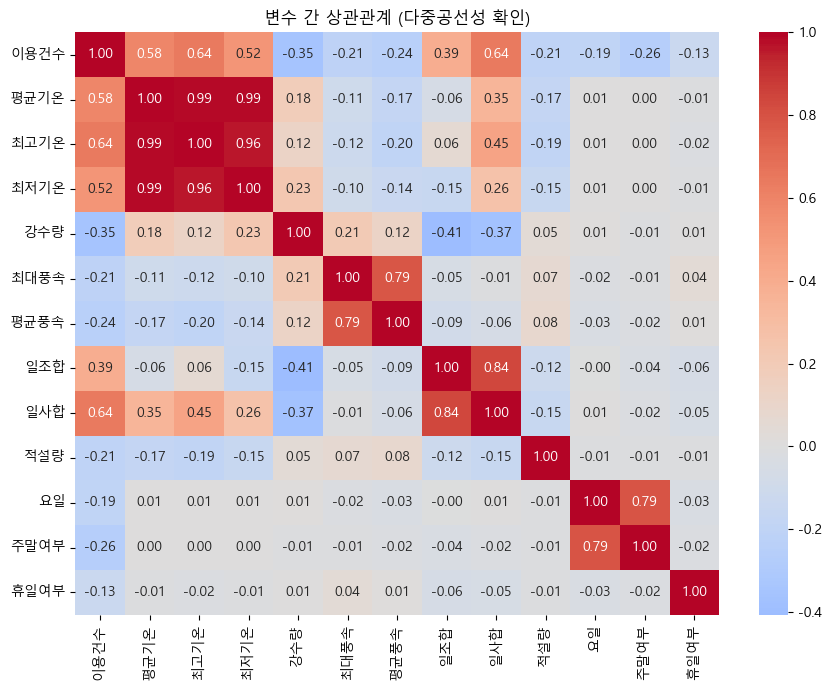

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 43.47it/s]


In [10]:
# =====================================================================
# 8. EDA - 상관관계 및 분포
# =====================================================================

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("numeric_cols :", numeric_cols)
corr = df[numeric_cols].corr()
print(type(df))

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("변수 간 상관관계 (다중공선성 확인)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_correlation_heatmap.png", dpi=150)
plt.show()
plt.close()


# EDA Report 생성 
profile = ProfileReport(df, title="Bike Demand Data Profile", explorative=True)
profile.to_file("output_data/bike_demand_profile.html")


In [11]:

print(f"[6] EDA 그래프 저장 완료: {OUTPUT_DIR}/01_correlation_heatmap.png, 02_temp_vs_rental.png")
print("\n    이용건수와의 상관계수:")
print(corr["이용건수"].sort_values(ascending=False).to_string())


[6] EDA 그래프 저장 완료: output_data/01_correlation_heatmap.png, 02_temp_vs_rental.png

    이용건수와의 상관계수:
이용건수    1.00
최고기온    0.64
일사합     0.64
평균기온    0.58
최저기온    0.52
일조합     0.39
휴일여부   -0.13
요일     -0.19
적설량    -0.21
최대풍속   -0.21
평균풍속   -0.24
주말여부   -0.26
강수량    -0.35


In [12]:
# =====================================================================
# 9. 변수 선택 및 월(Month) 변수 원핫인코딩 추가
# =====================================================================
# 9-1. 날짜 데이터에서 '월' 정보를 추출하여 문자열로 저장합니다.
df['월'] = df['날짜'].dt.month.astype(str)

# 9-2. 범주형 데이터인 '월'을 원핫인코딩(One-Hot Encoding)하여 12개의 이진 변수로 만듭니다.
df_encoded = pd.get_dummies(df, columns=['월'], prefix='월')

# 9-3. 생성된 '월_1', '월_2', ... '월_12' 컬럼 이름들을 가져옵니다.
month_cols = [col for col in df_encoded.columns if col.startswith('월_')]

# 9-4. 최종 학습에 사용할 기상 및 요일/휴일 피처에 월 원핫인코딩 피처를 추가합니다.
features = ["평균기온", "강수량", "평균풍속", "일조합", "주말여부", "휴일여부"] + month_cols
print(f"\n[7] 최종 사용 독립변수: {features}")

# 9-5. 대여량(이용건수)의 편향을 잡기 위해 로그 변환을 적용합니다.
df_encoded['이용건수'] = np.log1p(df_encoded['이용건수'])

X = df_encoded[features]
y = df_encoded["이용건수"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

# 9-6. 수치형 데이터 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)


[7] 최종 사용 독립변수: ['평균기온', '강수량', '평균풍속', '일조합', '주말여부', '휴일여부', '월_1', '월_10', '월_11', '월_12', '월_2', '월_3', '월_4', '월_5', '월_6', '월_7', '월_8', '월_9']


In [13]:
# =====================================================================
# 10. 모델 학습 및 비교
# =====================================================================
results = []

def evaluate(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    results.append({"모델": name, "R2": r2, "MSE": mse, "RMSE": rmse, "MAE": mae})
    print(f"  - {name:28s} R2={r2:.4f}  RMSE={rmse:,.1f}  MAE={mae:,.1f}")

print("\n[8] 모델 학습 및 평가")

# --- 모델 1: 단순 선형회귀 ---
model1 = LinearRegression().fit(X_train_scaled, y_train)
pred1 = model1.predict(X_test_scaled)
evaluate("선형회귀", y_test, pred1)

# --- 모델 2: 랜덤포레스트 (기본 파라미터) ---
model2 = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
model2.fit(X_train_scaled[features], y_train)
pred2 = model2.predict(X_test_scaled[features])
evaluate("랜덤포레스트(기본)", y_test, pred2)

# --- 모델 3: 의사결정트리 (기본 파라미터) ---
from sklearn.tree import DecisionTreeRegressor
model3 = DecisionTreeRegressor(random_state=RANDOM_STATE, max_depth=8)
model3.fit(X_train_scaled[features], y_train)
pred3 = model3.predict(X_test_scaled[features])
evaluate("결정트리(기본)", y_test, pred3)

best_model = model2
pred4 = pred2



[8] 모델 학습 및 평가
  - 선형회귀                         R2=0.7392  RMSE=0.3  MAE=0.2
  - 랜덤포레스트(기본)                   R2=0.8479  RMSE=0.2  MAE=0.1
  - 결정트리(기본)                     R2=0.6750  RMSE=0.3  MAE=0.2


In [14]:

# =====================================================================
# 11. 결과 비교표 출력 및 저장
# =====================================================================
result_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
print("\n[9] 모델 비교 결과 (R2 기준 정렬)")
print(result_df.to_string(index=False))
result_df.to_csv(f"{OUTPUT_DIR}/model_comparison.csv", index=False, encoding="utf-8-sig")



[9] 모델 비교 결과 (R2 기준 정렬)
        모델   R2  MSE  RMSE  MAE
랜덤포레스트(기본) 0.85 0.04  0.20 0.14
      선형회귀 0.74 0.07  0.26 0.19
  결정트리(기본) 0.67 0.09  0.29 0.18


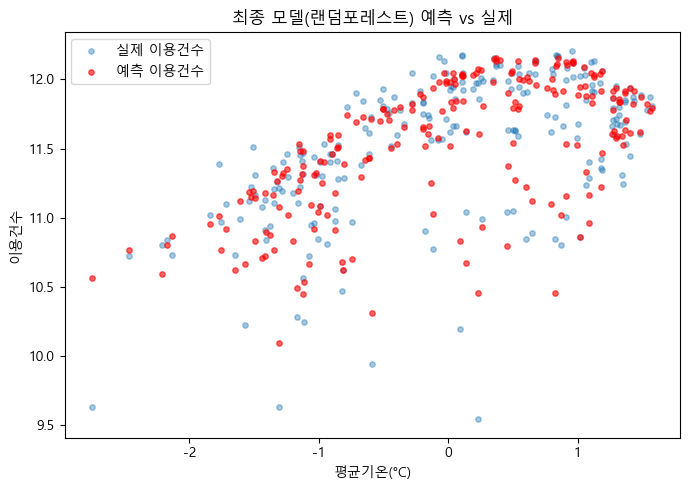

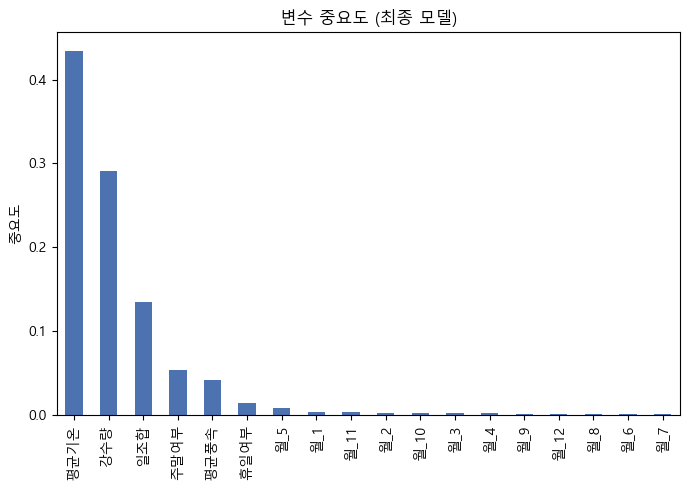


[10] 최종 그래프 저장 완료: output_data/03_final_model_fit.png, 04_feature_importance.png

변수 중요도:
평균기온   0.43
강수량    0.29
일조합    0.14
주말여부   0.05
평균풍속   0.04
휴일여부   0.01
월_5    0.01
월_1    0.00
월_11   0.00
월_2    0.00
월_10   0.00
월_3    0.00
월_4    0.00
월_9    0.00
월_12   0.00
월_8    0.00
월_6    0.00
월_7    0.00

모든 결과물이 'output_data/' 폴더에 저장되었습니다.


In [15]:
# =====================================================================
# 12. 최종(최적) 모델 결과 시각화
# =====================================================================
plt.figure(figsize=(7, 5))
plt.scatter(X_test_scaled["평균기온"], y_test, alpha=0.4, s=15, label="실제 이용건수")
plt.scatter(X_test_scaled["평균기온"], pred4, alpha=0.6, s=15, color="red", label="예측 이용건수")
plt.xlabel("평균기온(°C)")
plt.ylabel("이용건수")
plt.title("최종 모델(랜덤포레스트) 예측 vs 실제")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/03_final_model_fit.png", dpi=150)
plt.show()
plt.close()

importances = pd.Series(best_model.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(7, 5))
importances.plot(kind="bar", color="#4C72B0")
plt.ylabel("중요도")
plt.title("변수 중요도 (최종 모델)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/04_feature_importance.png", dpi=150)
plt.show()
plt.close()


print(f"\n[10] 최종 그래프 저장 완료: {OUTPUT_DIR}/03_final_model_fit.png, 04_feature_importance.png")
print("\n변수 중요도:")
print(importances.to_string())

print(f"\n모든 결과물이 '{OUTPUT_DIR}/' 폴더에 저장되었습니다.")
if demo_mode:
    print("\n※ 지금 실행된 결과는 DEMO(가상) 데이터 기준입니다.")
    print("   실제 데이터를 받아 RENTAL_FILE / WEATHER_FILE 경로를 수정한 뒤 다시 실행하세요.")


In [16]:
joblib.dump(best_model, "./model/bite_demand_prediction_model.pkl")
joblib.dump(features, "./model/features.pkl")
joblib.dump(holiday_dates, "./model/holiday_dates.pkl")

['./model/holiday_dates.pkl']

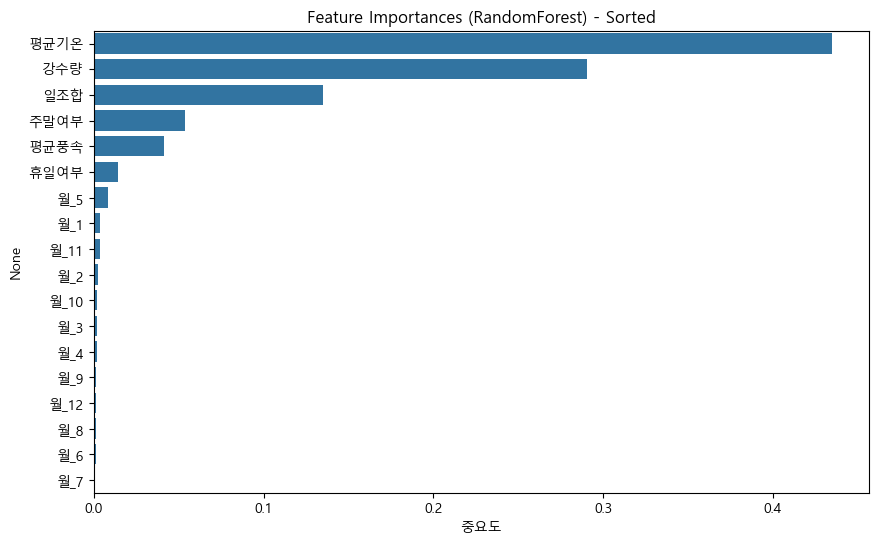

In [17]:
# 9. 피처 중요도 시각화 -- test 
importances = best_model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]
sorted_features = X.columns[sorted_idx]
sorted_importances = importances[sorted_idx]

plt.figure(figsize=(10, 6))
sns.barplot(
    x=sorted_importances,
    y=sorted_features
)
plt.title("Feature Importances (RandomForest) - Sorted")
plt.xlabel("중요도")
plt.show()

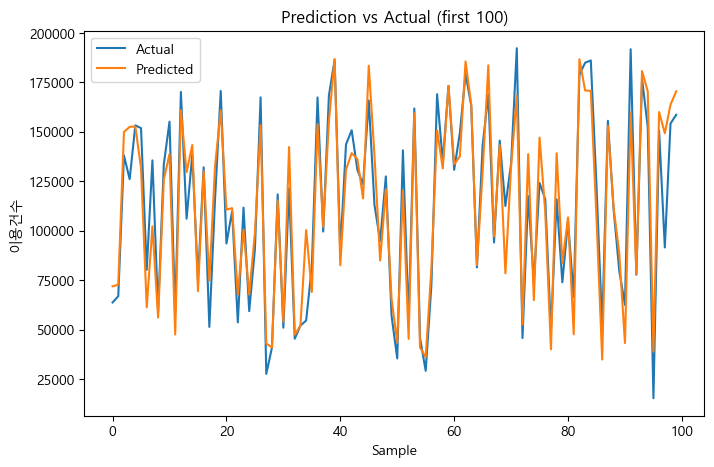

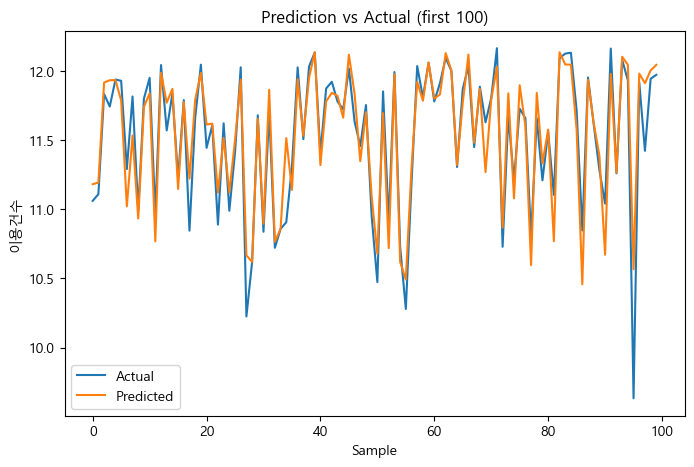

In [ ]:
# 10. 예측 vs 실제 시각화 역전환

# 역변환 (log1p → 원래 값)
y_test_exp = np.expm1(y_test)
y_pred_exp = np.expm1(pred4)

plt.figure(figsize=(8, 5))
plt.plot(y_test_exp.values[:100], label="Actual")  # 테스트 데이터의 첫 100개 샘플만 시각화
plt.plot(y_pred_exp[:100], label="Predicted") # 예측 데이터의 첫 100개 샘플만 시각화
plt.legend()
plt.title("Prediction vs Actual (first 100)")
plt.xlabel("Sample")
plt.ylabel("이용건수")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(y_test.values[:100], label="Actual")  # 테스트 데이터의 첫 100개 샘플만 시각화
plt.plot(pred4[:100], label="Predicted") # 예측 데이터의 첫 100개 샘플만 시각화
plt.legend()
plt.title("Prediction vs Actual (first 100)")
plt.xlabel("Sample")
plt.ylabel("이용건수")
plt.show()
